## Импорты

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy import signal
from scipy.io import loadmat
import scipy.io as sio
from numpy.fft import fft, fftfreq
import scipy.fftpack

plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8')

## Пункт 1

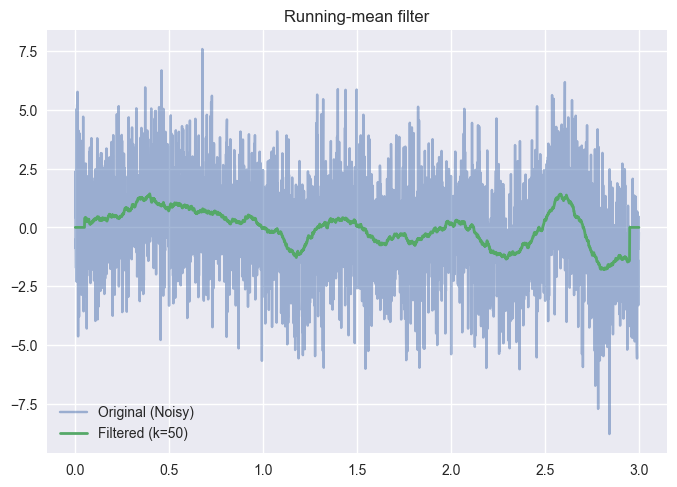

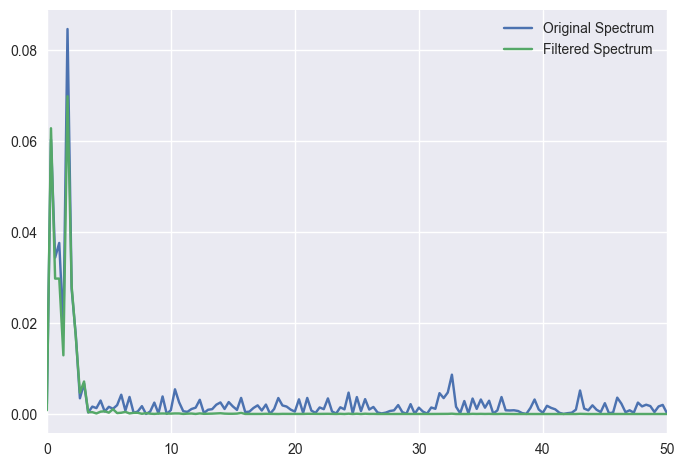

In [5]:

srate = 1000
time = np.arange(0, 3, 1/srate)
n = len(time)
p = 15 # количество гармоник
signal_orig = np.interp(np.linspace(0, p, n), np.arange(0, p), np.random.randn(p))
noise = np.random.randn(n) * 2
x = signal_orig + noise

k = 50 # параметр окна
y = np.zeros(n)
for t in range(k, n-k):
    y[t] = np.mean(x[t-k : t+k+1])

plt.plot(time, x, label='Original (Noisy)', alpha=0.5)
plt.plot(time, y, label=f'Filtered (k={k})', linewidth=2)
plt.title('Running-mean filter')
plt.legend()
plt.show()

hz = np.linspace(0, srate/2, int(n/2)+1)
x_fft = np.abs(scipy.fftpack.fft(x)/n)**2
y_fft = np.abs(scipy.fftpack.fft(y)/n)**2
plt.plot(hz, x_fft[:len(hz)], label='Original Spectrum')
plt.plot(hz, y_fft[:len(hz)], label='Filtered Spectrum')
plt.xlim([0, 50])
plt.legend()
plt.show()

Этот фильтр заменяет каждое значение сигнала средним арифметическим его соседей в окне шириной 2k+1.
На временном графике отфильтрованный сигнал более гладкий, очищенный от шума. В спектре видим подавление высоких частот, так как усреднение работает как фильтр низких частот (ФНЧ)

## Пункт 2

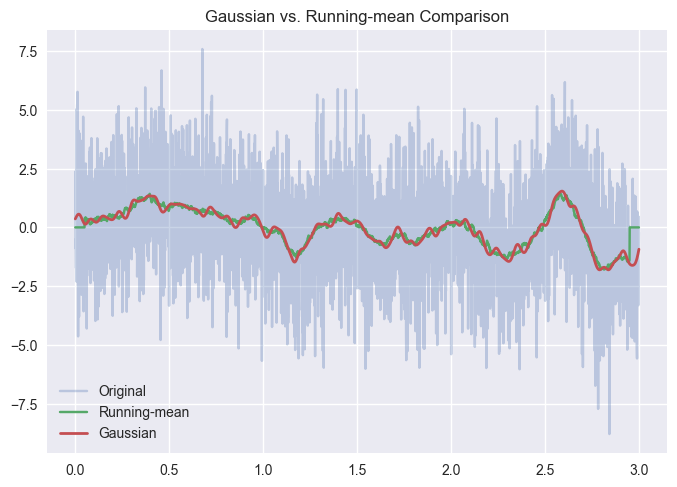

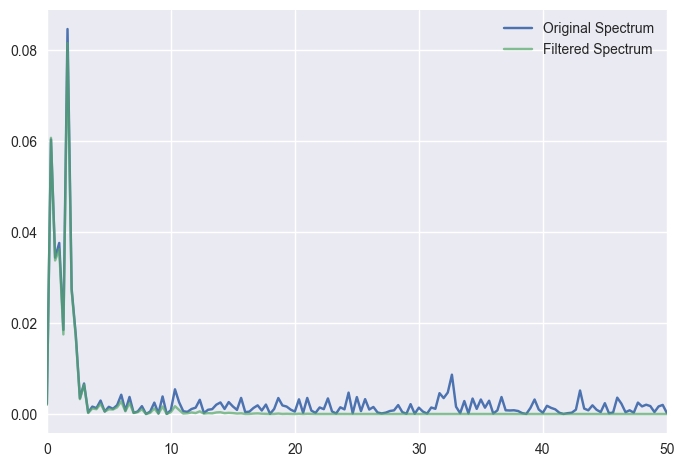

In [6]:

fwhm = 40 # full-width at half maximum в мс
k = 100
gtime = np.arange(-k, k)

gauss_win = np.exp(-4 * np.log(2) * gtime**2 / fwhm**2)
gauss_win = gauss_win / np.sum(gauss_win) # нормировка

# Свертка 
y_gauss = np.convolve(x, gauss_win, mode='same')

plt.plot(time, x, alpha=0.3, label='Original')
plt.plot(time, y, label='Running-mean')
plt.plot(time, y_gauss, label='Gaussian', linewidth=2)
plt.title('Gaussian vs. Running-mean Comparison')
plt.legend()
plt.show()

hz = np.linspace(0, srate/2, int(n/2)+1)
x_fft = np.abs(scipy.fftpack.fft(x)/n)**2
y_fft = np.abs(scipy.fftpack.fft(y)/n)**2
y_fft_gauss = np.abs(scipy.fftpack.fft(y_gauss)/n)**2
plt.plot(hz, x_fft[:len(hz)], label='Original Spectrum')
#plt.plot(hz, y_fft[:len(hz)], label='Filtered Spectrum')
plt.plot(hz, y_fft_gauss[:len(hz)], label='Filtered Spectrum', alpha = 0.7)
plt.xlim([0, 50])
plt.legend()
plt.show()

Здесь используется взвешенное среднее, где веса определяются функцией Гаусса. Это позволяет избежать резких ступенек обычного усреднения.
Фильтр Гаусса дает более гадкую кривую по сравнению со скользящим средним. Спектр очищенного сигнала имеет более плавный спад на высоких частотах.

## Пункт 3

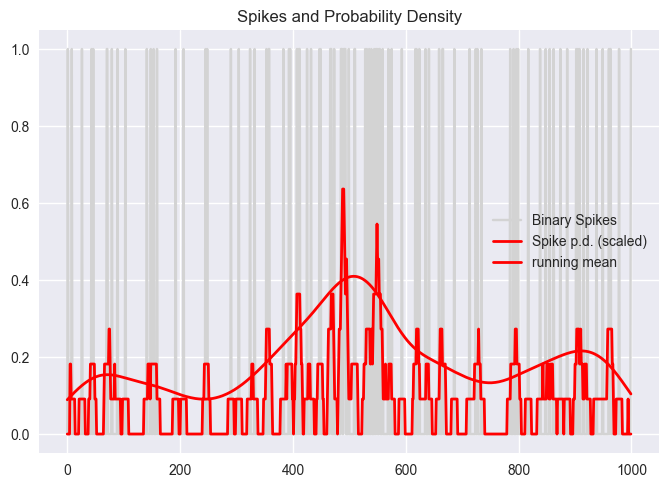

In [ ]:
n_spikes = 1000
spikes = np.zeros(n_spikes)
spike_idx = np.random.choice(range(n_spikes), 100, replace=False)
spikes[spike_idx] = 1

fwhm_spike = 100
g_spike_time = np.arange(-150, 150)
gauss_spike = np.exp(-4 * np.log(2) * g_spike_time**2 / fwhm_spike**2)
gauss_spike = gauss_spike / np.sum(gauss_spike)

k = 5
y = np.zeros(n_spikes)         
for t in range(k, n_spikes - k):
    y[t] = np.mean(spikes[t-k : t+k+1])

spike_pd = np.convolve(spikes, gauss_spike, mode='same')

plt.figure()
plt.plot(spikes, color='lightgray', label='Binary Spikes')
plt.plot(spike_pd * 2, color='red', linewidth=2, label='Spike p.d. (scaled)')
plt.plot(y, color='red', linewidth=2, label='running mean')  
plt.title('Spikes and Probability Density')
plt.legend()
plt.show()

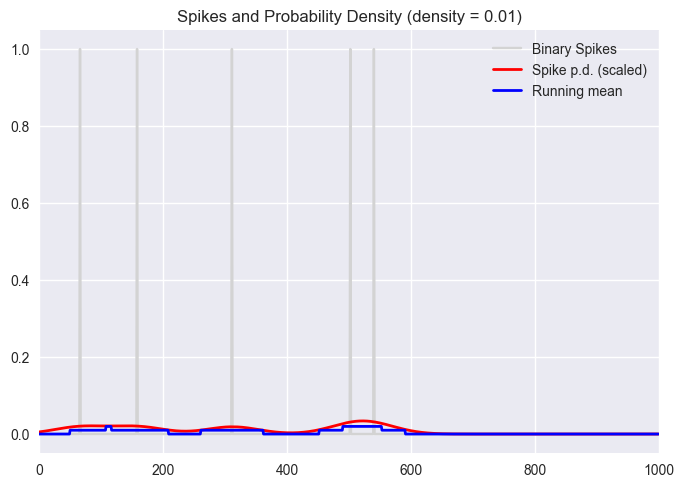

In [9]:
# ---------- Параметры ----------
n_spikes = 1000          
num_spikes = 5         
fwhm_spike = 100
k = 50                   


spikes = np.zeros(n_spikes)
spike_idx = np.random.choice(n_spikes, num_spikes, replace=False)
spikes[spike_idx] = 1


g_spike_time = np.arange(-150, 150)
gauss_spike = np.exp(-4 * np.log(2) * g_spike_time**2 / fwhm_spike**2)
gauss_spike = gauss_spike / np.sum(gauss_spike)


y = np.zeros(n_spikes)
for t in range(k, n_spikes - k):
    y[t] = np.mean(spikes[t-k : t+k+1])


spike_pd = np.convolve(spikes, gauss_spike, mode='same')


plt.figure()
plt.plot(spikes, color='lightgray', label='Binary Spikes')
plt.plot(spike_pd * 2, color='red', linewidth=2, label='Spike p.d. (scaled)')
plt.plot(y, color='blue', linewidth=2, label='Running mean')
plt.xlim(0, n_spikes)         
plt.title(f'Spikes and Probability Density (density = {num_spikes/n_spikes:.2f})')
plt.legend()
plt.show()

Сигнал состоит из редких импульсов амплитудой A=1V. Мы применяем сглаживание по Гауссу, чтобы получить плотность вероятности (интенсивность) этих всплесков.
Вместо отдельных вертикальных линий мы видим плавную кривую, которая показывает, в каких участках времени плотность пиков выше.

## Пункт 4

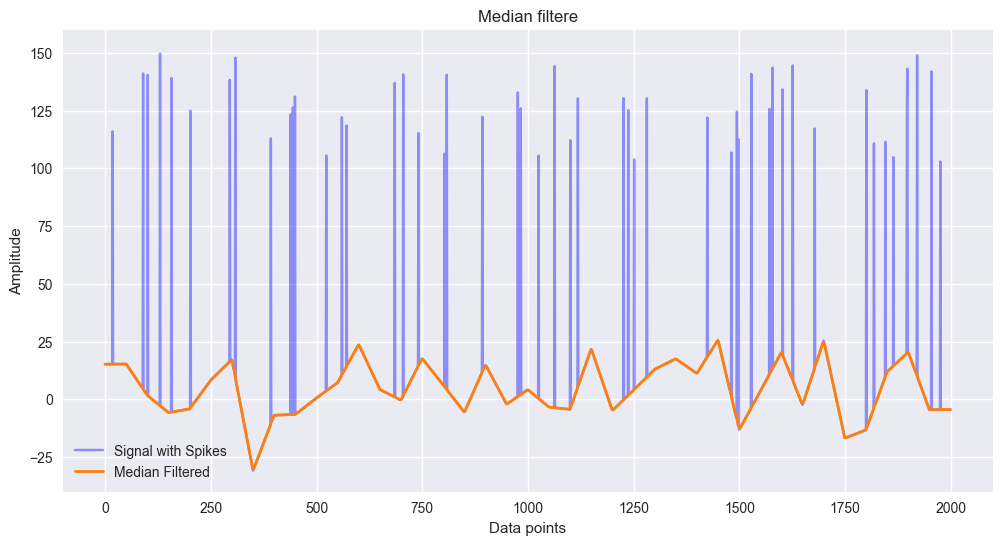

In [8]:
n = 2000
p = 40 

signal_base = np.interp(np.linspace(0, p, n), np.arange(0, p), np.random.randn(p)) * 15


x_spiky = signal_base.copy()
n_outliers = 50
outlier_idx = np.random.choice(range(n), n_outliers)

x_spiky[outlier_idx] = np.random.uniform(100, 150, n_outliers) 


limit = 80
x_thresholded = x_spiky.copy()
x_thresholded[x_thresholded > limit] = np.nan 


y_median = signal.medfilt(x_spiky, kernel_size=7)

plt.figure(figsize=(12, 6))
plt.plot(x_spiky, color='blue', alpha=0.4, label='Signal with Spikes')
plt.plot(y_median, color='#ff7f0e', linewidth=2, label='Median Filtered')

plt.title('Median filtere')
plt.xlabel('Data points')
plt.ylabel('Amplitude')
plt.legend()
plt.ylim([-40, 160]) 
plt.show()

## Пункт 5

C:\Windows\Temp\ipykernel_10340\3562503785.py:19: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(x, y, k)
C:\Windows\Temp\ipykernel_10340\3562503785.py:19: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(x, y, k)
C:\Windows\Temp\ipykernel_10340\3562503785.py:19: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(x, y, k)
C:\Windows\Temp\ipykernel_10340\3562503785.py:19: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(x, y, k)
C:\Windows\Temp\ipykernel_10340\3562503785.py:19: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(x, y, k)
C:\Windows\Temp\ipykernel_10340\3562503785.py:19: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(x, y, k)
C:\Windows\Temp\ipykernel_10340\3562503785.py:19: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(x, y, k)
C:\Windows\Temp\ipykernel_10340\3562503785.py:19: RankWarning: Polyfit may be poorly conditioned
  poly = np.polyfit(x

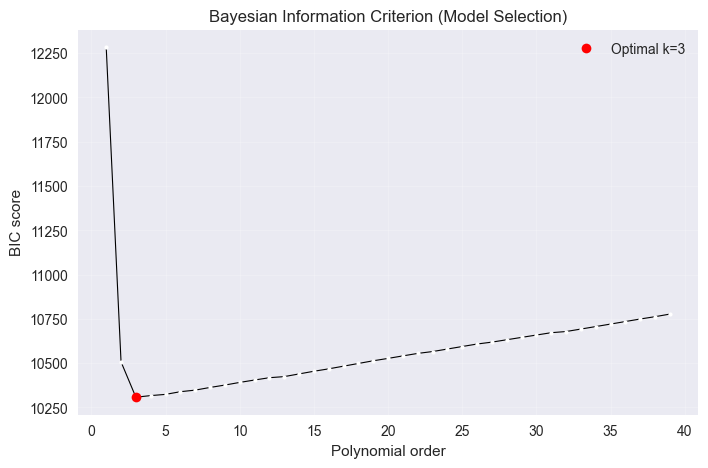

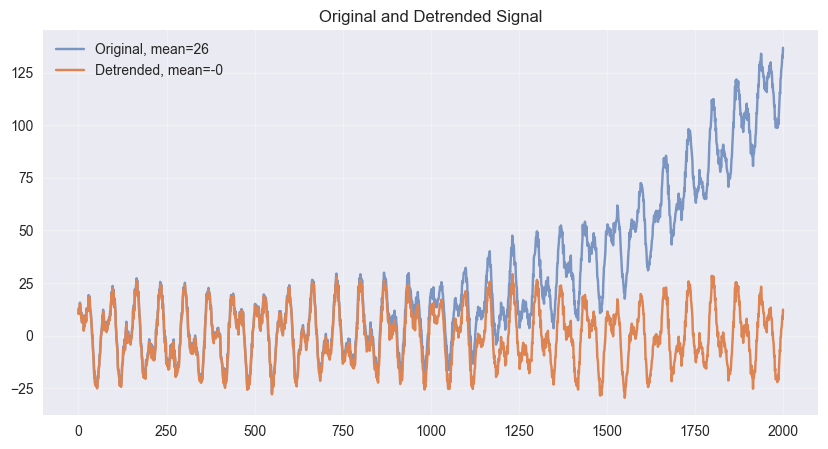

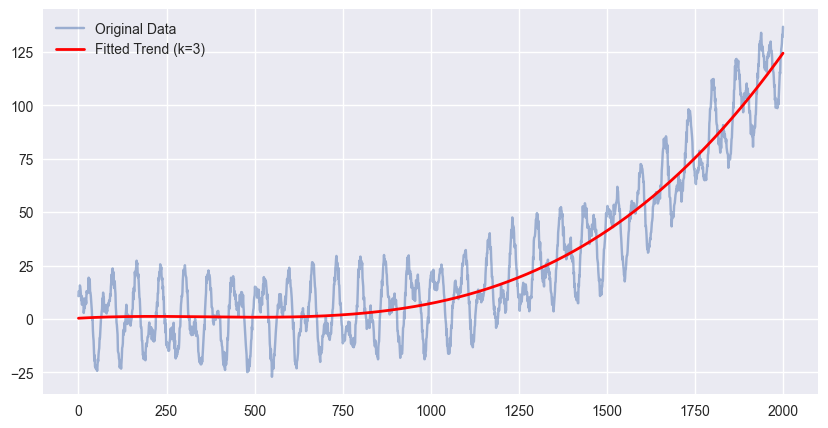

In [2]:
import numpy as np
import matplotlib.pyplot as plt

n = 2000
x = np.linspace(0, 4, n)

trend = 0.5 * x**4 + np.sin(4 * np.pi * 0.6 * x)  

pure_signal = 15 * np.sin(2 * np.pi * 7 * x) + 10 * np.cos(2 * np.pi * 15 * x)

noise = np.random.randn(n) * 2 

y = pure_signal + trend + noise

orders = np.arange(1, 40)
bic_values = []

for k in orders:
    poly = np.polyfit(x, y, k)
    y_hat = np.polyval(poly, x)
    resid = y - y_hat
    sigma2 = np.var(resid)
    
    bic = n * np.log(sigma2) + 2*(k + 1) * np.log(n)
    bic_values.append(bic)

best_k = orders[np.argmin(bic_values)]

plt.figure(figsize=(8, 5))
plt.plot(orders, bic_values, 'o-', color='black', markersize=3, markerfacecolor='white', linewidth=0.8)
plt.plot(best_k, bic_values[np.argmin(bic_values)], 'ro', label=f'Optimal k={best_k}')

plt.title('Bayesian Information Criterion (Model Selection)')
plt.xlabel('Polynomial order')
plt.ylabel('BIC score')
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

poly_coeffs = np.polyfit(x, y, best_k)
y_trend = np.polyval(poly_coeffs, x)
detrended = y - y_trend

plt.figure(figsize=(10, 5))
plt.plot(y, label=f'Original, mean={np.mean(y):.0f}', color='#4C72B0', alpha=0.7)
plt.plot(detrended, label=f'Detrended, mean={np.mean(detrended):.0f}', color='#DD8452')
plt.title('Original and Detrended Signal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(y, label='Original Data', alpha=0.5)
plt.plot(y_trend, label=f'Fitted Trend (k={best_k})', color='red', linewidth=2)
plt.legend()
plt.show()

## Пункт 6

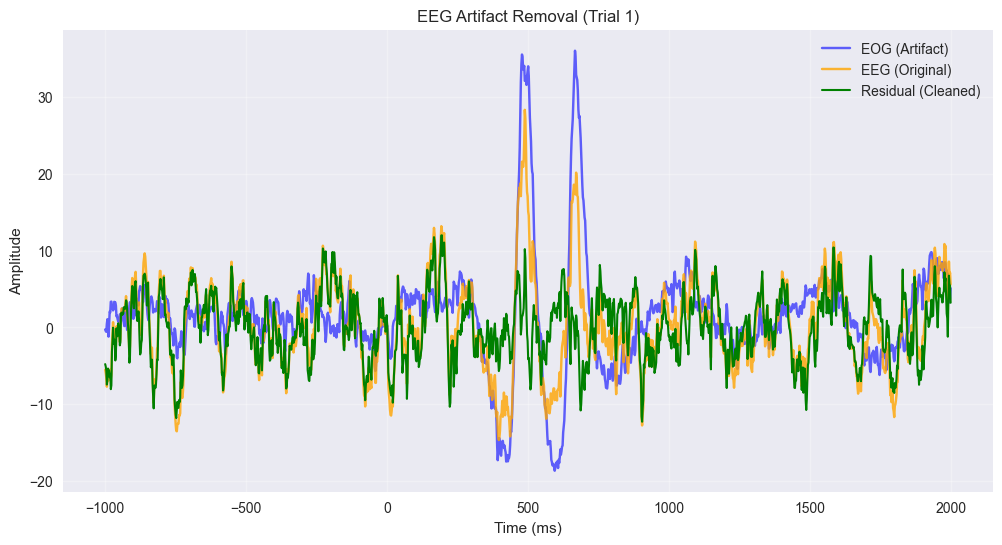

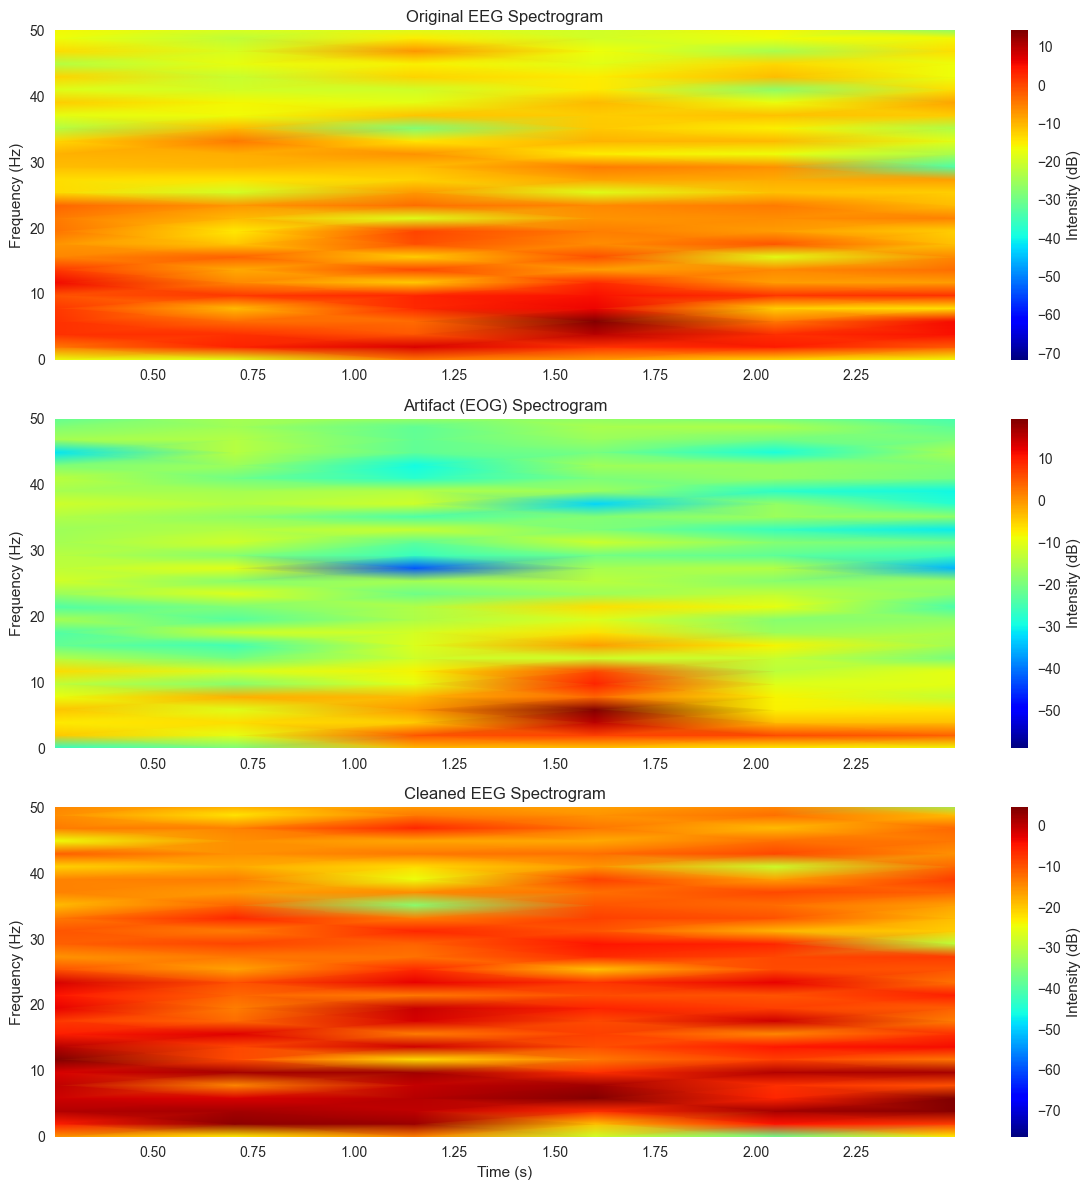

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy import signal


matdat = sio.loadmat('templateProjection.mat')
EEGdat = matdat['EEGdat']    # Матрица ЭЭГ (время x пробы)
eyedat = matdat['eyedat']    # Матрица ЭОГ (время x пробы)
timevec = matdat['timevec'].flatten() # Вектор времени

trial_idx = 0
y = EEGdat[:, trial_idx]     # целевой сигнал
eog = eyedat[:, trial_idx]   # Сигнал артефакта

T = len(y)
X = np.column_stack([np.ones(T), eog])

beta = np.linalg.inv(X.T @ X) @ X.T @ y

y_clean = y - (X @ beta)


plt.figure(figsize=(12, 6))
plt.plot(timevec, eog, label='EOG (Artifact)', color='blue', alpha=0.6)
plt.plot(timevec, y, label='EEG (Original)', color='orange', alpha=0.8)
plt.plot(timevec, y_clean, label='Residual (Cleaned)', color='green', linewidth=1.5)
plt.title(f'EEG Artifact Removal (Trial {trial_idx+1})')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

fs = 1 / ((timevec[1] - timevec[0]) / 1000)

signals = [y, eog, y_clean]
titles = ['Original EEG Spectrogram', 'Artifact (EOG) Spectrogram', 'Cleaned EEG Spectrogram']

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for i, sig in enumerate(signals):
    f, t_spec, Sxx = signal.spectrogram(sig, fs)
    im = axes[i].pcolormesh(t_spec, f, 10 * np.log10(Sxx), shading='gouraud', cmap='jet')
    axes[i].set_title(titles[i])
    axes[i].set_ylabel('Frequency (Hz)')
    axes[i].set_ylim(0, 50) 
    plt.colorbar(im, ax=axes[i], label='Intensity (dB)')

axes[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

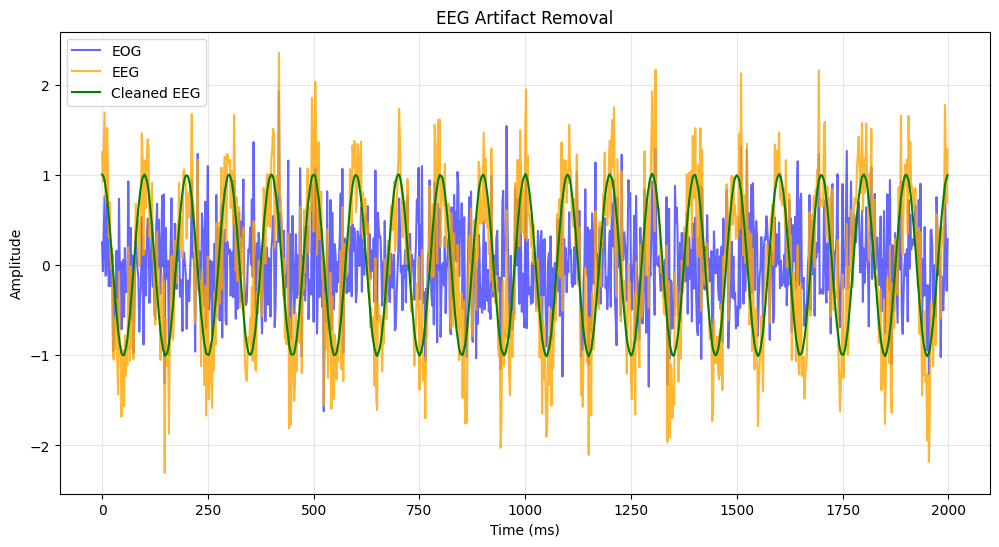

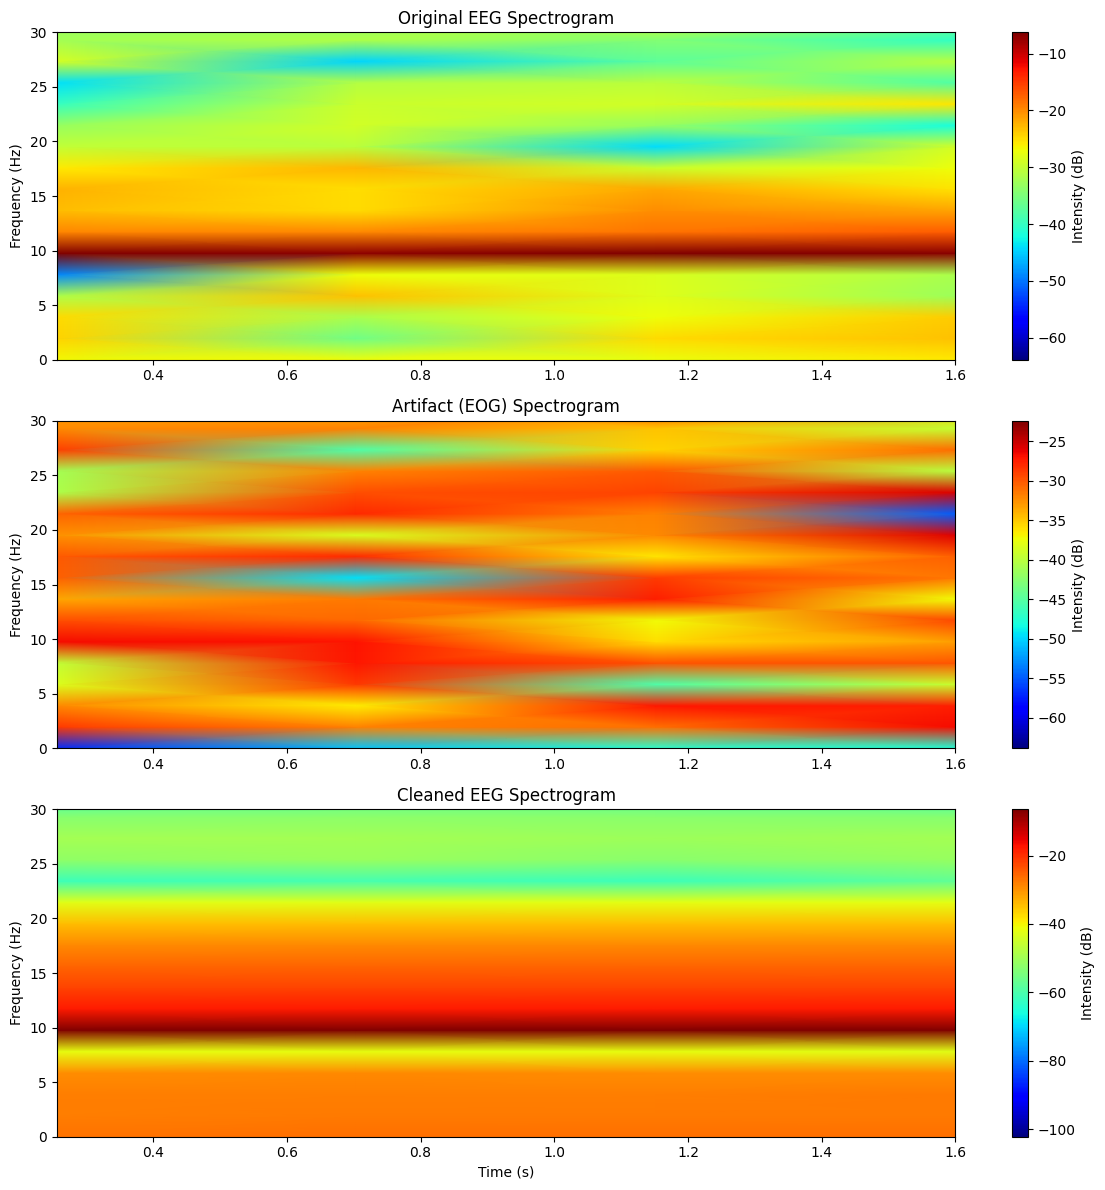

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 500                     
duration = 2.0               
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
timevec = t * 1000           

f_signal = 10.0
clean_signal = np.cos(2 * np.pi * f_signal * t)

np.random.seed(42)          
artifact_noise = 0.5 * np.random.randn(len(t))  

y = clean_signal + artifact_noise

T = len(y)
X = np.column_stack([np.ones(T), artifact_noise])   # eog = шум
beta = np.linalg.inv(X.T @ X) @ X.T @ y
y_clean = y - (X @ beta)


plt.figure(figsize=(12, 6))
plt.plot(timevec, artifact_noise, label='EOG', color='blue', alpha=0.6)
plt.plot(timevec, y, label='EEG', color='orange', alpha=0.8)
plt.plot(timevec, y_clean, label='Cleaned EEG', color='green', linewidth=1.5)
plt.title('EEG Artifact Removal')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


signals = [y, artifact_noise, y_clean]
titles = [
    'Original EEG Spectrogram',
    'Artifact (EOG) Spectrogram',
    'Cleaned EEG Spectrogram'
]

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
for i, sig in enumerate(signals):
    f, t_spec, Sxx = signal.spectrogram(sig, fs)
    im = axes[i].pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-12), shading='gouraud', cmap='jet')
    axes[i].set_title(titles[i])
    axes[i]. set_ylabel('Frequency (Hz)')
    axes[i].set_ylim(0, 30)
    plt.colorbar(im, ax=axes[i], label='Intensity (dB)')
axes[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()